## 2. Sentiment analysis with VADER
This part of the project focuses on conducting sentiment analysis on Steam Reviews and Reddit posts, in order to create time series with the average daily sentiment for each game for each platform as well as get the posts volume from Reddit. Sentiment analysis is done using the VADER lexicon with the use of the vaderSentiment library.

In [2]:
import pandas as pd
import os
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns
import zstandard as zstd
import json
import io
import ast
import re

In [16]:
sns.set_theme(style="whitegrid")

In [ ]:
analyser = SentimentIntensityAnalyzer()

# Firstly a general function for assigning sentiment labels using VADER is defined

def get_sentiment(text):
    """Map VADER compound score to a sentiment label.
    Thresholds:
      compound >= 0.1   -> positive
      compound <= -0.1  -> negative
      otherwise         -> neutral
    """
    scores = analyser.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.1:
        return "positive"
    elif compound <= -0.1:
        return "negative"
    else:
        return "neutral"

In [ ]:
#Loading the appids and names of the analysed games
game_names = pd.read_csv('filtered_games_by_data24-07-26.csv')

### 2.1 Review sentiment analysis
Firstly the sentiment analysis is done on Steam reviews. Firstly all the files are loaded into a table and filtered by date. Because the users are required to mark the review as positive or negative, this will allow for comparison between sentiment analysis scores and actual user ratings later on. THowever their scores might not reflect the actual sentiment, emotions and opinions written in the text itself and might sometimes contradict the score given. Therefore to get the emotions expressed by the player community, the sentiment scores and not user scores will be used in the final analysis. The review statistics like the volume of the reviews for each game, the number of positive reviews and the ratio of positive to negative reviews as well as the number of entries missing the review text are all saved into a separate table for exploration and data cleaning purposes.

In [ ]:
start_2025 = pd.to_datetime('2025-01-01')
end_2025 = pd.to_datetime('2025-12-31')

folder = '2025_reviews'
statistics_reviews = []
reviews = pd.DataFrame(columns=['date', 'appid', 'voted_up', 'text'])
for filename in os.listdir(folder):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder, filename), index_col = 0, sep = ',')
        df.index = pd.to_datetime(df.index)
        appid = re.search(r'\d+', filename).group()
        df['appid'] = int(appid)
        df = df.loc[(df.index >= start_2025) & (df.index <= end_2025)]
        df.reset_index(inplace = True)
        df.drop(columns = ['votes_helpful'], inplace = True)
        reviews = pd.concat([reviews, df], ignore_index=True)
        
        voted_up = df['voted_up'].sum()
        count = df.shape[0]
        percentage_voted_up = voted_up/count
        missing_data = df["text"].isna().sum()
        statistics_reviews.append((int(appid), voted_up, count, percentage_voted_up.round(2), missing_data))

statistics_reviews_df = pd.DataFrame(statistics_reviews, columns=['appid', 'voted_up', 'count', 'percentage_voted_up', 'missing_data'])
statistics_reviews_df


,appid,voted_up,count,percentage_voted_up,missing_data
0,105600,45205,47212,0.96,1
1,107410,5692,6377,0.89,1
2,1085660,11898,19670,0.60,2
3,108600,30466,32624,0.93,3
4,1091500,49327,52007,0.95,5
...,...,...,...,...,...
108,916440,2666,3477,0.77,0
109,945360,14521,15910,0.91,0
110,960090,23657,24526,0.96,1
111,961200,1193,1801,0.66,0


#### 2.1.1 Exploration of review data

In [37]:
reviews.describe()

,date,appid,voted_up,text
count,1866678,1866678,1866678,1866554
unique,365,113,2,1369253
top,2025-11-25 00:00:00,2767030,True,The Best Game
freq,15111,170174,1579546,39251


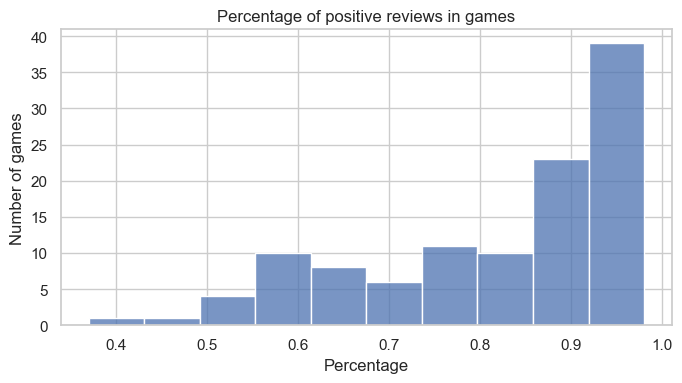

In [ ]:
# A visualization of the different ratios of positive to negative reviews in games

plt.figure(figsize=(7, 4))
axes = sns.histplot(statistics_reviews_df['percentage_voted_up'], bins=10)
plt.title("Percentage of positive reviews in games")
plt.xlabel("Percentage")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

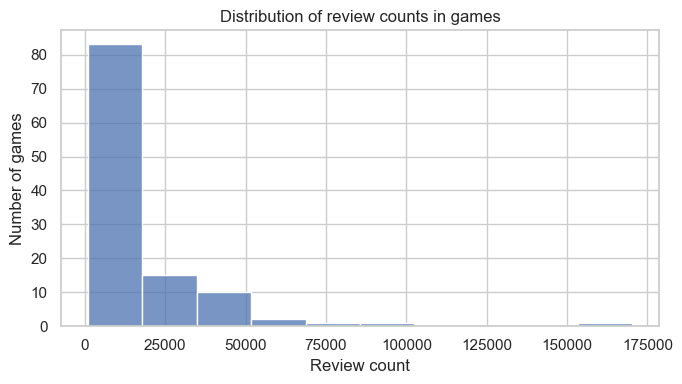

In [ ]:
#A graph showing the distribution of the number of reviews for each game

plt.figure(figsize=(7, 4))
axes = sns.histplot(statistics_reviews_df['count'], bins = 10)
plt.title("Distribution of review counts in games")
plt.xlabel("Review count")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

In [ ]:
#Checking the total number of saved reviews
statistics_reviews_df['count'].sum()

np.int64(1866678)

#### 2.1.2 Conducting the analysis

In [ ]:
tqdm.pandas(desc="Calculating Sentiment")

#Removing reviews with missing text
reviews.dropna(inplace=True)
sentiment = reviews['text'].progress_apply(get_sentiment)

#Appending the VADER labels to the table with reviews
reviews['sentiment'] = sentiment

Calculating Sentiment:   0%|          | 0/1866554 [00:00<?, ?it/s]

Note on VADER speed - the calculating time for the total number of 1866554 reviews was about ~28 min. This shows that VADER is a fairly quick, even if a simple method of extracting sentiment.

In [ ]:
#Saving the result for reproducibility
reviews.to_csv('all_reviews_with_sentiment.csv', index=False)

In [14]:
reviews = pd.read_csv('all_reviews_with_sentiment.csv')

In [ ]:
#Checking the results of the analysis
reviews.head()

,date,appid,voted_up,text,sentiment
0,2025-12-31 00:00:00,105600,True,fun game and so much content especially with f...,positive
1,2025-12-31 00:00:00,105600,False,flying tortoise,neutral
2,2025-12-31 00:00:00,105600,True,would recomend,neutral
3,2025-12-31 00:00:00,105600,True,the block,negative
4,2025-12-31 00:00:00,105600,True,What a classic. This game actually stands the ...,positive


Because the users' scores are also avaliable in case of reviews, VADER labels will be converted into a binary score, just like user scores, either positive or negative. Because the neutral reviews contain a fairly small amount of reviews and many of them were marked as positive by the users, they will be treated as positive for the binary conversion. This binary sentiment score will be used for comparison, to check the accuracy of the analysis and explore the differences.

In [16]:
reviews['sentiment_binary'] = reviews['sentiment'].apply(lambda x: 1 if x == "positive" or x == "neutral" else 0)

In [69]:
# Calculate accuracy and F1 score
sentiment_scores = reviews['sentiment_binary']
actual_labels = reviews['voted_up'].astype(int)

accuracy = accuracy_score(actual_labels, sentiment_scores)
f1 = f1_score(actual_labels, sentiment_scores, average="weighted")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

Accuracy: 0.8415
Weighted F1 Score: 0.8248


In [70]:
print(classification_report(actual_labels, sentiment_scores))

              precision    recall  f1-score   support

           0       0.48      0.29      0.36    287125
           1       0.88      0.94      0.91   1579429

    accuracy                           0.84   1866554
   macro avg       0.68      0.61      0.63   1866554
weighted avg       0.82      0.84      0.82   1866554



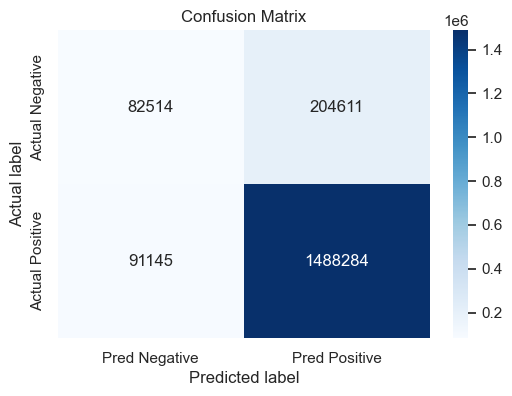

In [71]:
# Generate confusion matrix
cm = confusion_matrix(actual_labels, sentiment_scores)
cm_df = pd.DataFrame(cm, index=["Actual Negative", "Actual Positive"], columns=["Pred Negative", "Pred Positive"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

From the result of the comparison, the accuracy, F1 score and the confusing matrix all look acceptable and don't point at any major flaws and differences between the user scores and VADER scores. As mentioned, some misclassifications might result from the user score contradicting the text itself or from the aggregation of positive and neutral results. Better results could also possibly be achieved by experimenting with standard thresholds set for generating the labels.
Next step is to compute the average sentiment and user scores for each game and average daily user scores for exploration purposes and the average daily sentiment scores for each game for further use in the analysis.

In [ ]:
#Calculating average sentiments and user scores for each game, as well as daily average user scores and sentiment scores for each game
average_sentiment = pd.DataFrame(reviews.groupby('appid')['sentiment_binary'].mean())
average_user_score = pd.DataFrame(reviews.groupby('appid')['voted_up'].mean())
average_sentiment_daily = pd.DataFrame(reviews.groupby(['appid', 'date'])['sentiment_binary'].mean().round(2))
real_sentiment_daily = pd.DataFrame(reviews.groupby(['appid', 'date'])['voted_up'].mean())

In [119]:
average_sentiment

,sentiment_binary
appid,
570,0.958661
4000,0.960250
39210,0.894277
105600,0.947512
107410,0.907779
...,...
2399830,0.866647
2537590,0.841299
2707930,0.967752


In [ ]:
average_user_score

In [120]:
average_sentiment_daily

sentiment_binary
appid   date                        
570     2025-01-01          0.934211
        2025-01-02          1.000000
        2025-01-03          0.989691
        2025-01-04          0.916667
        2025-01-05          0.925926
...                              ...
2840770 2025-12-27          0.927083
        2025-12-28          0.944444
        2025-12-29          0.904255
        2025-12-30          0.942857
        2025-12-31          0.909091

[41021 rows x 1 columns]

In [121]:
real_sentiment_daily

voted_up
appid   date                
570     2025-01-01  0.763158
        2025-01-02  0.740741
        2025-01-03  0.948454
        2025-01-04   0.84375
        2025-01-05  0.790123
...                      ...
2840770 2025-12-27  0.739583
        2025-12-28  0.744444
        2025-12-29  0.765957
        2025-12-30  0.809524
        2025-12-31  0.840909

[41021 rows x 1 columns]

### 2.2 Reddit posts sentiment analysis
#### 2.2.1 Extracting posts
Before loading reddit posts into a table, because the files are in a .zst format, they need to be processed to extract posts. They are immediately filtered by date and only the ones posted in the relevant time frame are saved. Posts are extracted and saved in batches to avoid losing data as a result of crashing or memory issues. 

In [ ]:
#Extracting subreddit names from the file saved in a previous part of the project
subreddits = pd.read_csv('game_subreddits29-07-26.csv')
subreddits['subreddits'] = subreddits['subreddits'].apply(ast.literal_eval)
subreddits_to_analyse = subreddits.explode('subreddits')

In [ ]:
subreddit_dump_folder = "C:/Users/magda/My stuff/Projekty/get data magisterka/reddit_new/reddit/subreddits25"

start_2025_unix = int(start_2025.timestamp())
end_2025_unix = int(end_2025.timestamp())

#Defining a function to extract posts from a given subreddit to a separate CSV file for each subreddit, while filtering them by date

def extract_subreddit_posts(subreddit, output_file):
    posts = []
    chunk_size = 10000
    with open(f'{subreddit_dump_folder}/{subreddit}_submissions.zst', 'rb') as f:
        dctx = zstd.ZstdDecompressor()
        stream_reader = dctx.stream_reader(f)
        text_stream = io.TextIOWrapper(stream_reader, encoding='utf-8')
        for line in tqdm(text_stream, desc=f"Scanning {subreddit}", position=1, leave=False):
            try:
                post = json.loads(line)
                created_utc = int(post.get('created_utc'))
                if not created_utc or not (start_2025_unix <= created_utc < end_2025_unix):
                    continue
                title = post.get('title', '')
                body = post.get('selftext', '')
                full_text = f"{title} {body}"
                posts.append({
                    'post_id': post.get('id'),
                    'created_utc': created_utc,
                    'subreddit': post.get('subreddit'),
                    'text': full_text,
                })
            except json.JSONDecodeError:
                continue
            if len(posts) >= chunk_size:
                df = pd.DataFrame(posts)
                df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')
                df.to_csv(output_file, index=False, mode='a', header=not os.path.exists(output_file), sep=';')
                posts.clear()

        if posts:
            df = pd.DataFrame(posts)
            df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')
            df.to_csv(output_file, index=False, mode='a', header=not os.path.exists(output_file), sep=';')


In [ ]:
for sub in tqdm(subreddits_to_analyse['subreddits'], desc="Analyzing Subreddits"):
    if os.path.exists(f'{subreddit_dump_folder}/{sub}_submissions.zst'):
        extract_subreddit_posts(sub, f'2025_reddit_posts/{sub}.csv')

Analyzing Subreddits:   0%|          | 0/125 [00:00<?, ?it/s]

Scanning marvelrivals: 0it [00:00, ?it/s]

Scanning Warframe: 0it [00:00, ?it/s]

Scanning apexlegends: 0it [00:00, ?it/s]

Scanning forhonor: 0it [00:00, ?it/s]

...

Scanning outerwilds: 0it [00:00, ?it/s]

Scanning planetzoo: 0it [00:00, ?it/s]

Scanning 2007scape: 0it [00:00, ?it/s]

Scanning predecessorgame: 0it [00:00, ?it/s]

Scanning playark: 0it [00:00, ?it/s]

Todo: dodać wykresy ilości postów

In [ ]:
#Exploring the number of posts for each subreddit, as well as checking for missing data. Loading all posts into a single table

folder_subreddits = '2025_reddit_posts'
statistics_reddit = []
posts = pd.DataFrame(columns=['date', 'subreddit', 'text'])
for filename in os.listdir(folder_subreddits):
    df = pd.read_csv(os.path.join(folder_subreddits, filename), sep = ';')
    df.drop(columns = ['post_id'], inplace = True)
    df.rename(columns = {"created_utc" : "date"}, inplace = True)
    posts = pd.concat([posts, df], ignore_index=True)
    subreddit = filename.replace('.csv','')

    count = df.shape[0]
    missing_data = df["text"].isna().sum()
    statistics_reddit.append((subreddit, count, missing_data))

statistics_reddit_df = pd.DataFrame(statistics_reddit, columns=['subreddit', 'count', 'missing_data'])
statistics_reddit_df

,subreddit,count,missing_data
0,2007scape,118633,0
1,7daystodie,16477,0
2,AmongUs,8766,0
3,anno1800,2164,0
4,apexlegends,89532,0
...,...,...,...
109,WEPES,4500,0
110,WorldofTanks,30984,0
111,WorldOfTanksBlitz,13234,0
112,WorldOfWarships,17133,0


#### 2.2.2 Conducting the sentiment analysis

In [ ]:
tqdm.pandas(desc="Calculating Sentiment")

#Removing all missing observations
posts.dropna(inplace=True)
sentiment = posts['text'].progress_apply(get_sentiment)

#Appending the sentiment labels to the table
posts['sentiment'] = sentiment

Calculating Sentiment:   0%|          | 0/5037908 [00:00<?, ?it/s]

Note on VADER speed: for a total of 5037908 posts the calculating time was around 2h 26 min which indicates a lower speed than in the case of reviews

#### 2.2.3 Preparing for further analysis
Because each game can have multiple subreddits assigned to it, the posts need to be grouped according to the game they belong to. VADER labels will also be converted to a binary form following the same rules as were set for reviews for consistency and for further analysis in later parts of the project.

In [ ]:
#Creating and applying a mapping of subreddits and which appids they belong to
appid_dict = subreddits_to_analyse.set_index('subreddits')['appid'].to_dict()
posts['appid'] = posts['subreddit'].map(appid_dict)

In [126]:
posts.head()

,date,subreddit,text,sentiment,sentiment_binary,appid
0,2025-01-01 00:00:52,2007scape,Have a question about the game or the subreddi...,neutral,1,1343370.0
1,2025-01-01 00:08:50,2007scape,Used up all my RNG,neutral,1,1343370.0
2,2025-01-01 00:14:59,2007scape,HAPPY NEW YEAR SCAPERS FROM ME TO YOU! ❤️🫶🥰,positive,1,1343370.0
3,2025-01-01 00:17:16,2007scape,Help me please. My phone is blocked from loggi...,neutral,1,1343370.0
4,2025-01-01 00:20:51,2007scape,Balance elemental I feel like im praying right...,neutral,1,1343370.0


In [ ]:
#Saving the results for reproducibility
posts.to_csv('all_posts_with_sentiment.csv', index=False)

In [3]:
posts = pd.read_csv('all_posts_with_sentiment.csv')

In [4]:
posts.head()

,date,subreddit,text,sentiment,sentiment_binary,appid
0,2025-01-01 00:00:52,2007scape,Have a question about the game or the subreddi...,neutral,1,1343370.0
1,2025-01-01 00:08:50,2007scape,Used up all my RNG,neutral,1,1343370.0
2,2025-01-01 00:14:59,2007scape,HAPPY NEW YEAR SCAPERS FROM ME TO YOU! ❤️🫶🥰,positive,1,1343370.0
3,2025-01-01 00:17:16,2007scape,Help me please. My phone is blocked from loggi...,neutral,1,1343370.0
4,2025-01-01 00:20:51,2007scape,Balance elemental I feel like im praying right...,neutral,1,1343370.0


In [128]:
posts['sentiment_binary'] = posts['sentiment'].apply(lambda x: 1 if x == "positive" or x == "neutral" else 0)

In [ ]:
#Cleaning up the table
posts['date'] = pd.to_datetime(posts['date'], unit='s')
posts['date'] = posts['date'].dt.date

Average sentiments are calculated for each subreddit and game, as well as daily average sentiments for each subreddit and for exploration purposes. Average daily sentiment is calculated for each game for further analysis in the project.

In [10]:
average_sentiment_reddit = pd.DataFrame(posts.groupby('subreddit')['sentiment_binary'].mean().round(2))
average_sentiment_reddit_games = pd.DataFrame(posts.groupby('appid')['sentiment_binary'].mean().round(2))
average_sentiment_reddit_daily = pd.DataFrame(posts.groupby(['subreddit', 'date'])['sentiment_binary'].mean().round(2))
average_sentiment_reddit_daily_games = posts.groupby(['appid', 'date']).agg(
    sentiment_binary=('sentiment_binary', 'mean'),
    post_count=('sentiment_binary', 'count')
).reset_index()
average_sentiment_reddit_daily_games['sentiment_binary'] = average_sentiment_reddit_daily_games['sentiment_binary'].round(2)

In [18]:
average_sentiment_daily.to_csv('average_sentiment_reviews_daily.csv', index=True)

In [ ]:
#Saving results for reproducibility
average_sentiment_reddit_daily_games.to_csv('average_sentiment_reddit_daily.csv', index=True)